# Laboratorio#1

In [ ]:
import cv2
import numpy as np

In [7]:
import matplotlib.pyplot as plt

## Problema # 1

In [4]:
def filtrar_color(imagen, color):
    # 1. Hacemos una copia para no alterar la imagen original
    img_out = imagen.copy()
    
    # 2. Evaluamos el parámetro 'color' según las reglas del problema
    if color == 1:
        # Solo Azul: Apagamos Verde (1) y Rojo (2)
        img_out[:, :, 1] = 0
        img_out[:, :, 2] = 0
        
    elif color == 2:
        # Solo Verde: Apagamos Azul (0) y Rojo (2)
        img_out[:, :, 0] = 0
        img_out[:, :, 2] = 0
        
    elif color == 3:
        # Solo Rojo: Apagamos Azul (0) y Verde (1)
        img_out[:, :, 0] = 0
        img_out[:, :, 1] = 0
        
    elif color == 10:
        # Rojo y Verde: Apagamos Azul (0)
        img_out[:, :, 0] = 0
        
    elif color == 20:
        # Verde y Azul: Apagamos Rojo (2)
        img_out[:, :, 2] = 0
        
    elif color == 30:
        # Azul y Rojo: Apagamos Verde (1)
        img_out[:, :, 1] = 0
        
    else:
        print("Error: El código de color ingresado no es válido.")
        
    # 3. Devolvemos la imagen procesada
    return img_out

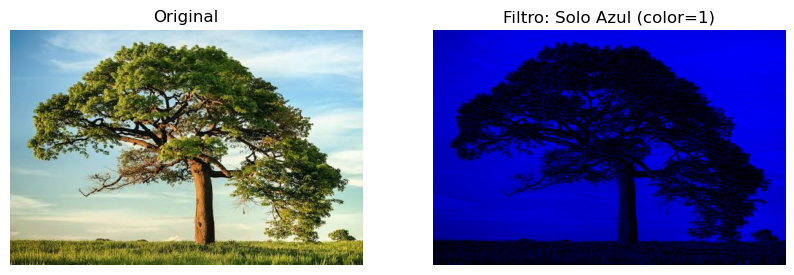

In [10]:


# Cargamos una imagen de prueba
# cv2 lee en BGR, pero matplotlib muestra en RGB, así que la convertimos para verla bien en el notebook
img_original = cv2.imread('arbol.jpg') 
img_rgb = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

# Probamos la función con el valor 1 (Solo Azul)
# Pasamos img_rgb para que los índices 0,1,2 coincidan visualmente con B,G,R si usas plt.imshow()
img_azul = filtrar_color(img_original, 1)

# Mostramos el resultado usando matplotlib
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Filtro: Solo Azul (color=1)")
plt.imshow(cv2.cvtColor(img_azul, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

## Problema # 2

In [11]:


def reconstruir_imagen_color(img1, img2, img3):
    """
    Recibe 3 imágenes en escala de grises (representando los 3 canales)
    y devuelve la imagen combinada a color.
    
    Nota: OpenCV asume el orden BGR (Canal 0: Azul, Canal 1: Verde, Canal 2: Rojo).
    """
    # Si las imágenes fueron cargadas como escala de grises de 1 solo canal,
    # cv2.merge() las une directamente a lo largo del tercer eje.
    imagen_color = cv2.merge([img1, img2, img3])
    
    return imagen_color

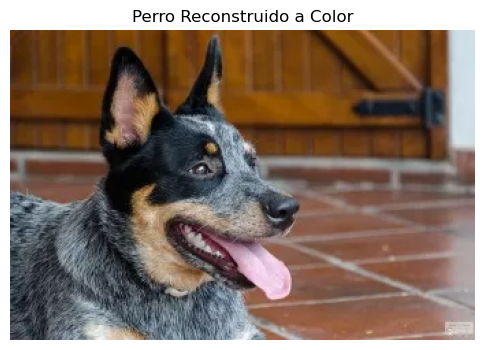

In [13]:
# 1. Cargar las 3 imágenes en escala de grises especificando la carpeta 'perro/'
canal_azul  = cv2.imread('perro/perro_salida_gray_azul.jpg', cv2.IMREAD_GRAYSCALE)
canal_verde = cv2.imread('perro/perro_salida_gray_verde.jpg', cv2.IMREAD_GRAYSCALE)
canal_rojo  = cv2.imread('perro/perro_salida_gray_rojo.jpg', cv2.IMREAD_GRAYSCALE)

# 2. Reconstruir la imagen pasando los canales en orden BGR
imagen_perro_bgr = cv2.merge([canal_azul, canal_verde, canal_rojo])

# 3. Mostrar el resultado en pantalla
plt.figure(figsize=(6, 6))

# Convertimos BGR a RGB solo para que matplotlib lo pinte con los colores reales
plt.imshow(cv2.cvtColor(imagen_perro_bgr, cv2.COLOR_BGR2RGB))
plt.title("Perro Reconstruido a Color")
plt.axis('off')

plt.show()

## Problema #3

In [14]:
def crear_escala_grises_3d(imagen):
    """
    Recibe una imagen a color y devuelve 3 imágenes en escala de grises,
    correspondientes a los canales Azul, Verde y Rojo (BGR en OpenCV).
    """
    # Descomponemos la imagen en los 3 canales de color
    # En OpenCV, el canal 0 es Azul (B), 1 es Verde (G) y 2 es Rojo (R)
    canal_azul, canal_verde, canal_rojo = cv2.split(imagen)
    
    # Devolvemos las 3 imágenes en escala de grises
    return canal_azul, canal_verde, canal_rojo

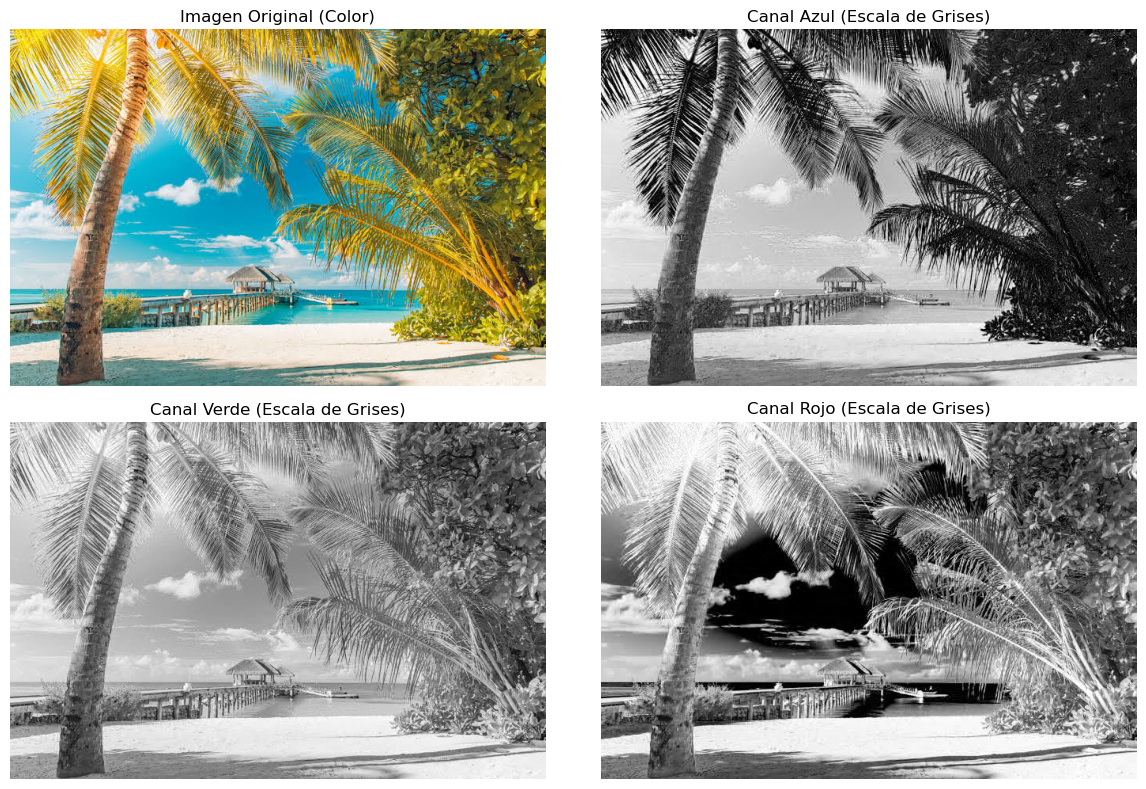

In [15]:
# 1. Cargamos una imagen de prueba distinta a la del perro

nombre_imagen = 'playa.jpg' 
img_original = cv2.imread(nombre_imagen)

# 2. Ejecutamos nuestra función para obtener las 3 imágenes en escala de grises
gray_azul, gray_verde, gray_rojo = crear_escala_grises_3d(img_original)

# 3. Guardamos los resultados como archivos (Opcional pero recomendable)
cv2.imwrite('resultado_gray_azul.jpg', gray_azul)
cv2.imwrite('resultado_gray_verde.jpg', gray_verde)
cv2.imwrite('resultado_gray_rojo.jpg', gray_rojo)

# 4. Graficamos la imagen original y las 3 salidas en escala de grises
plt.figure(figsize=(12, 8))

# Subplot 1: Imagen Original a Color
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original (Color)")
plt.axis('off')

# Subplot 2: Canal Azul en escala de grises
plt.subplot(2, 2, 2)
plt.imshow(gray_azul, cmap='gray')
plt.title("Canal Azul (Escala de Grises)")
plt.axis('off')

# Subplot 3: Canal Verde en escala de grises
plt.subplot(2, 2, 3)
plt.imshow(gray_verde, cmap='gray')
plt.title("Canal Verde (Escala de Grises)")
plt.axis('off')

# Subplot 4: Canal Rojo en escala de grises
plt.subplot(2, 2, 4)
plt.imshow(gray_rojo, cmap='gray')
plt.title("Canal Rojo (Escala de Grises)")
plt.axis('off')

plt.tight_layout()
plt.show()

## Problema #4

In [16]:
def mostrar_histogramas_con_media(imagen):
    """
    Calcula la escala de grises mediante promedio aritmético manual,
    y muestra los histogramas de cada canal de color (B, G, R) y escala de grises,
    incluyendo una línea vertical con el valor medio de la distribución.
    """
    # 1. Separar canales (OpenCV usa el orden BGR)
    canal_b = imagen[:, :, 0]
    canal_g = imagen[:, :, 1]
    canal_r = imagen[:, :, 2]
    
    # 2. Escala de grises por PROMEDIO ARITMÉTICO MANUAL (sin OpenCV)
    # Convertimos a float para evitar desbordamiento al sumar enteros uint8
    grises_promedio = (canal_b.astype(np.float32) + 
                       canal_g.astype(np.float32) + 
                       canal_r.astype(np.float32)) / 3.0
    
    grises_promedio = grises_promedio.astype(np.uint8)
    
    # Lista de canales con su nombre y color para graficar
    canales_info = [
        (canal_b, 'Canal Azul (Blue)', 'blue'),
        (canal_g, 'Canal Verde (Green)', 'green'),
        (canal_r, 'Canal Rojo (Red)', 'red'),
        (grises_promedio, 'Escala de Grises (Promedio)', 'gray')
    ]
    
    # 3. Crear figura de 2x2 para mostrar los 4 histogramas
    plt.figure(figsize=(14, 10))
    
    for i, (canal, titulo, color) in enumerate(canales_info, 1):
        plt.subplot(2, 2, i)
        
        # Calcular la media del canal
        media = np.mean(canal)
        
        # Graficar el histograma de frecuencias (256 bins para rango 0-255)
        plt.hist(canal.ravel(), bins=256, range=[0, 256], color=color, alpha=0.7, edgecolor='black', linewidth=0.2)
        
        # Añadir la línea vertical de la media de la distribución
        plt.axvline(media, color='black', linestyle='dashed', linewidth=2, 
                    label=f'Media: {media:.2f}')
        
        # Configurar títulos y etiquetas
        plt.title(f'Histograma - {titulo}')
        plt.xlabel('Intensidad de Píxel (0-255)')
        plt.ylabel('Frecuencia (N° de Píxeles)')
        plt.legend(loc='upper right')
        plt.grid(True, linestyle=':', alpha=0.6)
        
    plt.tight_layout()
    plt.show()

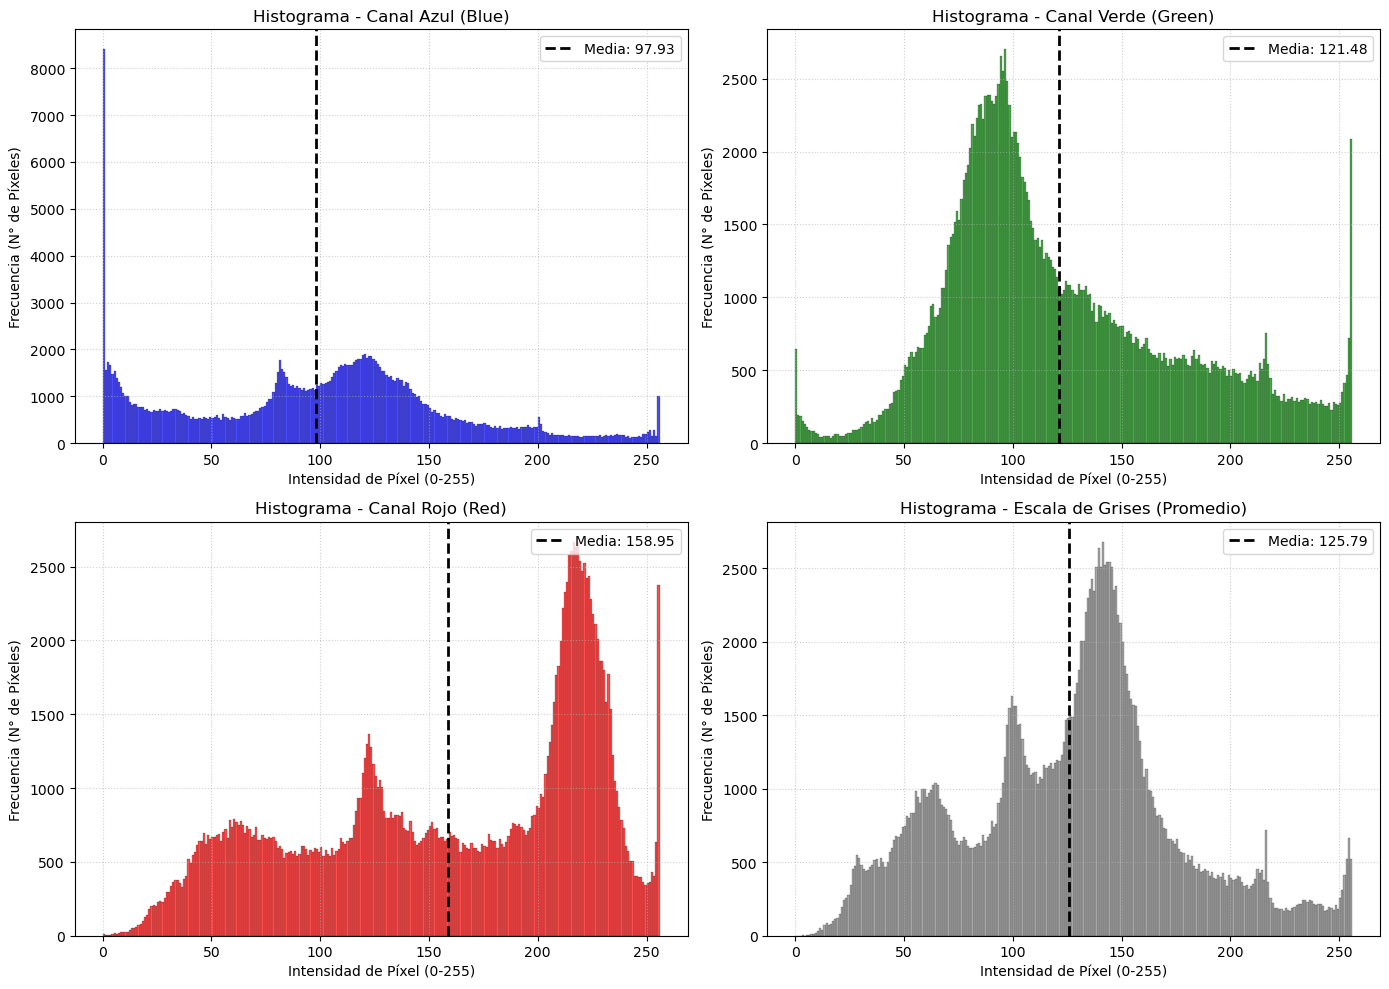

In [17]:
# Cargar la imagen a color
img_prueba = cv2.imread('flor.jpg') 

# Ejecutar la función
mostrar_histogramas_con_media(img_prueba)

## Problema #5

El enfoque de escala de grises ponderado (o Weighted Grayscale / Luminance Method) convierte una imagen a color en una de escala de grises asignando diferentes pesos (porcentajes) a los tres canales de color ($R$, $G$, $B$), en lugar de calcular una simple media donde todos valen un tercio ($33.3\%$).

Si se usa un promedio simple $\frac{R + G + B}{3}$, las imágenes resultantes pierden contraste percibido. Al aplicar un promedio ponderado, la conversión respeta la percepción biológica del brillo en la visión humana.

In [18]:
def escala_grises_ponderada(imagen, w_r=0.299, w_g=0.587, w_b=0.114):
    """
    Convierte una imagen a color a escala de grises utilizando el enfoque ponderado.
    
    Parámetros:
        imagen: Imagen leída con OpenCV (formato BGR).
        w_r: Peso para el canal Rojo (Default: 0.299)
        w_g: Peso para el canal Verde (Default: 0.587)
        w_b: Peso para el canal Azul (Default: 0.114)
    """
    # 1. Extraer canales en formato BGR de OpenCV
    canal_b = imagen[:, :, 0].astype(np.float32)
    canal_g = imagen[:, :, 1].astype(np.float32)
    canal_r = imagen[:, :, 2].astype(np.float32)
    
    # 2. Aplicar la suma ponderada
    grises_ponderado = (w_r * canal_r) + (w_g * canal_g) + (w_b * canal_b)
    
    # 3. Asegurar que los valores permanezcan entre 0 y 255 y convertir a uint8
    grises_ponderado = np.clip(grises_ponderado, 0, 255).astype(np.uint8)
    
    return grises_ponderado

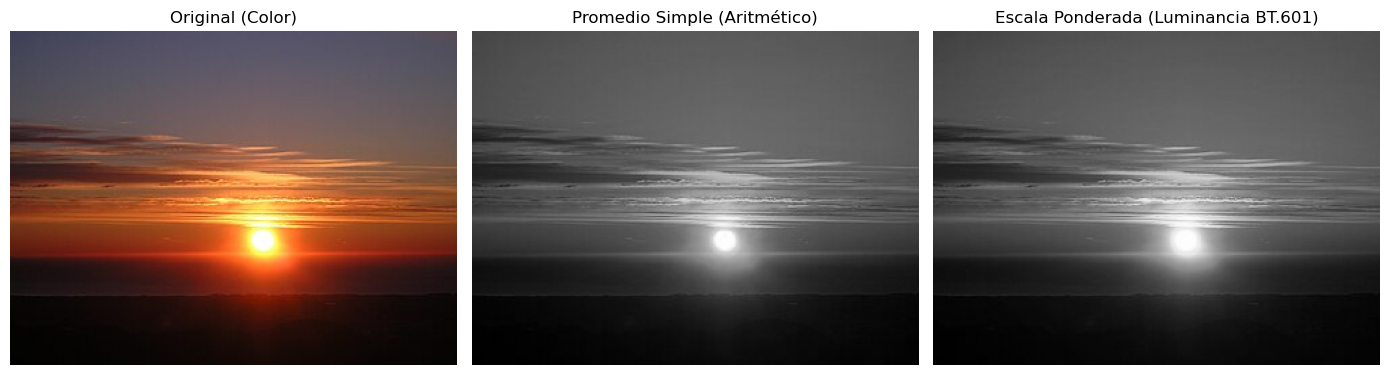

In [19]:
# 1. Cargar una imagen de prueba
img_color = cv2.imread('sol.jpg') # Reemplaza por el nombre de tu imagen

# 2. Calcular la escala de grises por Promedio Aritmético (Problema 4)
grises_promedio = (img_color[:, :, 0].astype(np.float32) + 
                   img_color[:, :, 1].astype(np.float32) + 
                   img_color[:, :, 2].astype(np.float32)) / 3.0
grises_promedio = grises_promedio.astype(np.uint8)

# 3. Calcular la escala de grises Ponderada (Problema 5)
grises_ponderada = escala_grises_ponderada(img_color)

# 4. Mostrar la comparación de los resultados
plt.figure(figsize=(14, 5))

plt.subplot(1, 3, 1)
plt.title("Original (Color)")
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Promedio Simple (Aritmético)")
plt.imshow(grises_promedio, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Escala Ponderada (Luminancia BT.601)")
plt.imshow(grises_ponderada, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

## Problema #6

### Investigación del Espacio de Color HSV

#### 1. ¿En qué consiste el espacio de color HSV?

El espacio de color **HSV** (*Hue, Saturation, Value* — Matiz, Saturación, Valor) es una representación cilíndrica del modelo de color RGB alineada de forma más cercana a la manera en que la percepción humana interpreta y describe los colores.

A diferencia del espacio RGB (donde un color se define por la mezcla de luz Roja, Verde y Azul), HSV separa la información cromática (el color puro) de la información de iluminación (el brillo).

Sus tres componentes principales son:

*   **Hue (Matiz - $H$):** Representa el tipo de color en un círculo cromático de 0° a 360°:
    *   $0^\circ / 360^\circ$: Rojo
    *   $120^\circ$: Verde
    *   $240^\circ$: Azul
    *(En OpenCV, este rango se escala de 0 a 179 para caber en un entero de 8 bits).*
*   **Saturation (Saturación - $S$):** Indica la pureza o intensidad del color (cuánta cantidad de gris tiene mezclada). Varía de 0% (completamente gris o neutro) a 100% (color puro y vívido). En OpenCV va de $0$ a $255$.
*   **Value (Valor / Brillo - $V$):** Representa la luminosidad o brillo del color. Varía de 0% (negro absoluto) a 100% (brillo máximo del color). En OpenCV va de $0$ a $255$.

---

#### 2. ¿Cómo se mapean o convierten los colores de RGB a HSV?

El mapeo matemático desde un color $RGB$ normalizado ($R, G, B \in [0, 1]$) hacia $HSV$ se realiza en función del valor máximo ($\max$) y mínimo ($\min$) de los tres canales de color:

1. **Cálculo del Valor ($V$):**
   $$V = \max(R, G, B)$$

2. **Cálculo de la Saturación ($S$):**
   Si $V = 0$, entonces $S = 0$. De lo contrario:
   $$S = \frac{\max(R, G, B) - \min(R, G, B)}{\max(R, G, B)}$$

3. **Cálculo del Matiz ($H$):**
   Si $\max = \min$, $H = 0$. En otro caso, depende de qué canal sea el dominante:
   
   $$H = \begin{cases} 
   60^\circ \times \left( \frac{G - B}{\max - \min} \pmod 6 \right), & \text{si } \max = R \\
   60^\circ \times \left( \frac{B - R}{\max - \min} + 2 \right), & \text{si } \max = G \\
   60^\circ \times \left( \frac{R - G}{\max - \min} + 4 \right), & \text{si } \max = B
   \end{cases}$$

---

#### 3. Utilidad práctica en Visión por Computadora

* **Segmentación por Color:** En RGB, un cambio en la iluminación (sombra o brillo) altera drásticamente los tres valores ($R, G, B$). En HSV, el tono del color se mantiene constante en el canal $H$, por lo que segmentar objetos por su color es mucho más robusto a cambios de luz.
* **Filtros e Histogramas:** Permite realizar ecualizaciones de contraste modificando solo el canal $V$ sin alterar la tonalidad cromática de la imagen.